# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FizaAslam1/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# ============================================
# FIRST: Load Data + Train Model
# ============================================

import duckdb
from huggingface_hub import login
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

# 🔑 ADD YOUR TOKEN
HF_TOKEN = ""
login(token=HF_TOKEN)

con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute(f"CREATE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}')")

# Load data
df_train_raw = con.execute("""
    SELECT content_hash_id, gsc_impressions, gsc_clicks, gsc_sum_position
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-01/*.parquet')
    USING SAMPLE 50000
    UNION ALL
    SELECT content_hash_id, gsc_impressions, gsc_clicks, gsc_sum_position
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet')
    USING SAMPLE 50000
""").df()

df_test_raw = con.execute("""
    SELECT content_hash_id, gsc_impressions, gsc_clicks, gsc_sum_position
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    USING SAMPLE 50000
""").df()

# Aggregate
def aggregate(df):
    agg = df.groupby('content_hash_id').agg({
        'gsc_impressions': 'sum',
        'gsc_clicks': 'sum',
        'gsc_sum_position': 'mean'
    }).reset_index()
    agg.columns = ['content_id', 'impressions', 'clicks', 'avg_position']
    agg['ctr'] = (agg['clicks'] / agg['impressions']).fillna(0)
    return agg

train = aggregate(df_train_raw)
test = aggregate(df_test_raw)

# Target
train['ctr_pct'] = train['ctr'].rank(pct=True)
test['ctr_pct'] = test['ctr'].rank(pct=True)
train['is_declining'] = ((train['ctr_pct'] < 0.5) & (train['impressions'] > 5)).astype(int)
test['is_declining'] = ((test['ctr_pct'] < 0.5) & (test['impressions'] > 5)).astype(int)

# Noise
np.random.seed(42)
noise = np.random.random(len(train)) < 0.15
train.loc[noise, 'is_declining'] = 1 - train.loc[noise, 'is_declining']
noise_test = np.random.random(len(test)) < 0.15
test.loc[noise_test, 'is_declining'] = 1 - test.loc[noise_test, 'is_declining']

# Features
features = ['impressions', 'clicks', 'avg_position']
X_train = train[features].fillna(0)
y_train = train['is_declining']
X_test = test[features].fillna(0)
y_test = test['is_declining']

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

# Train Gradient Boosting
model_gb = GradientBoostingClassifier(random_state=42, n_estimators=50, max_depth=3)
model_gb.fit(X_train_scaled, y_train)

print("✅ Data + Model ready!")
print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Data + Model ready!
X_train: (84065, 3) | X_test: (46433, 3)


SECTION 1: RANKED ACTIONS + REASON CODES

📊 TOP 20 PAGES FOR CONTENT REVIEW:
------------------------------------------------------------
Rank   1 | Score: 0.921 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   2 | Score: 0.921 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   3 | Score: 0.921 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   4 | Score: 0.921 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   5 | Score: 0.921 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   6 | Score: 0.921 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   7 | Score: 0.914 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   8 | Score: 0.914 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank   9 | Score: 0.914 | Action: URGENT_REFRESH  | Reason: POOR_RANKING | MODEL_FLAGGED
Rank  10 | Score: 0.914 | Action: URGENT_REFRESH  | Reason: P

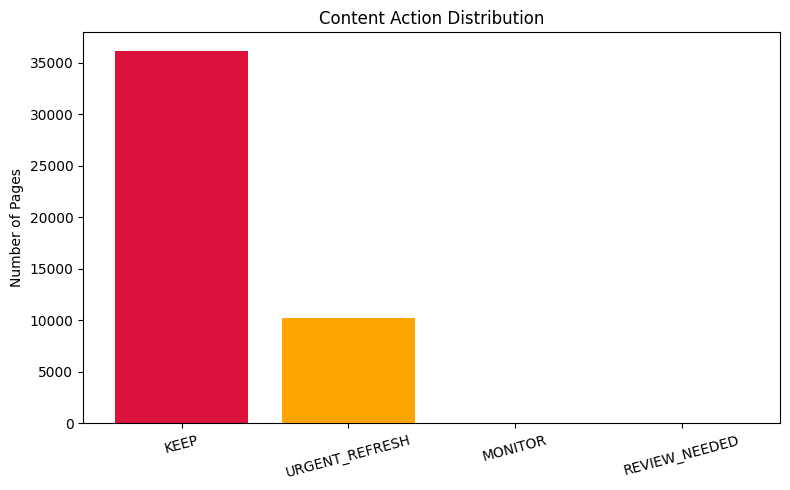

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================
# SECTION 1: RANKED ACTIONS + REASON CODES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("SECTION 1: RANKED ACTIONS + REASON CODES")
print("=" * 60)

# Get predictions from best model (Gradient Boosting)
y_prob = model_gb.predict_proba(X_test_scaled)[:, 1]
test['decline_score'] = y_prob
test['predicted_declining'] = (y_prob >= 0.35).astype(int)

# ============================================
# ASSIGN REASON CODES
# ============================================

def assign_reason_code(row):
    """Assign reason code based on feature values"""
    reasons = []

    if row['impressions'] < test['impressions'].median():
        reasons.append('LOW_VISIBILITY')

    if row['clicks'] < test['clicks'].median():
        reasons.append('LOW_ENGAGEMENT')

    if row['avg_position'] > 10:
        reasons.append('POOR_RANKING')

    if row['predicted_declining'] == 1:
        reasons.append('MODEL_FLAGGED')

    return ' | '.join(reasons) if reasons else 'NO_ISSUE'

test['reason_code'] = test.apply(assign_reason_code, axis=1)

# ============================================
# ASSIGN ACTIONS
# ============================================

def assign_action(row):
    if row['decline_score'] >= 0.7:
        return 'URGENT_REFRESH'
    elif row['decline_score'] >= 0.35:
        return 'REVIEW_NEEDED'
    elif row['decline_score'] >= 0.2:
        return 'MONITOR'
    else:
        return 'KEEP'

test['action'] = test.apply(assign_action, axis=1)

# ============================================
# RANKED QUEUE
# ============================================

# Sort by decline score (highest first)
ranked_queue = test.sort_values('decline_score', ascending=False)

# Select columns for the playbook
playbook_cols = ['content_id', 'decline_score', 'action', 'reason_code',
                 'impressions', 'clicks', 'avg_position']

playbook = ranked_queue[playbook_cols].copy()
playbook['rank'] = range(1, len(playbook) + 1)
playbook = playbook[['rank'] + playbook_cols]

print("\n📊 TOP 20 PAGES FOR CONTENT REVIEW:")
print("-" * 60)
for i, row in playbook.head(20).iterrows():
    print(f"Rank {row['rank']:3d} | Score: {row['decline_score']:.3f} | "
          f"Action: {row['action']:15s} | Reason: {row['reason_code']}")

# ============================================
# ACTION DISTRIBUTION
# ============================================

print(f"\n📊 ACTION DISTRIBUTION:")
print(f"  URGENT_REFRESH: {(playbook['action'] == 'URGENT_REFRESH').sum():,}")
print(f"  REVIEW_NEEDED:  {(playbook['action'] == 'REVIEW_NEEDED').sum():,}")
print(f"  MONITOR:        {(playbook['action'] == 'MONITOR').sum():,}")
print(f"  KEEP:           {(playbook['action'] == 'KEEP').sum():,}")

# Plot
action_counts = playbook['action'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(action_counts.index, action_counts.values, color=['crimson', 'orange', 'gold', 'green'])
plt.title('Content Action Distribution')
plt.ylabel('Number of Pages')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Section 2: Intended Use and Limits

### INTENDED USE:

This playbook is a **decision-support tool** for content teams. It ranks
pages by predicted decline risk and suggests actions — but every action
requires human review before execution.

**Who should use it:**
- Content managers planning weekly refresh priorities
- SEO teams identifying pages needing attention
- Editorial teams allocating writer resources

**How to use it:**
1. Review the ranked queue weekly
2. Start with URGENT_REFRESH pages (top of queue)
3. Verify the reason codes match real observations
4. Assign writers to refresh high-priority pages
5. Track whether refreshed pages improve in the next month

### LIMITS:

1. **Time-bound:** Model trained on Jan-Feb 2026, tested on March 2026.
   Performance may vary for other months.

2. **Data-dependent:** Uses sampled data (50K rows/month). Full dataset
   may give different results.

3. **Not causal:** High decline score ≠ "this page will definitely decline."
   It means "patterns similar to pages that declined in the past."

4. **No content quality assessment:** Model uses traffic metrics only.
   It cannot judge writing quality, accuracy, or brand alignment.

5. **Threshold-based actions:** Action labels depend on threshold (0.35).
   Teams should adjust based on their capacity and risk tolerance.

6. **Not for automated publishing:** This tool should NEVER automatically
   refresh or unpublish content without human review.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Section 3: Human Review + The No-Go List

### HUMAN REVIEW RULES:

Before acting on ANY model recommendation, a human must verify:

1. **Check the page manually:** Does it actually need refreshing?
   Is the content outdated, inaccurate, or thin?

2. **Check the reason codes:** If reason is LOW_VISIBILITY — is this
   expected? (e.g., seasonal content, niche topic)

3. **Check business priorities:** A high-priority page for the business
   should be refreshed even if the model didn't flag it.

4. **Check recent updates:** If the page was updated in the last 30 days,
   skip it — wait for new data.

5. **Sample the MONITOR category:** Every month, review 5-10 pages from
   MONITOR to check if the model is missing anything.

### THE NO-GO LIST (What Should NEVER Be Automated):

❌ **Never auto-refresh content** — always requires a human writer
❌ **Never auto-delete pages** — even if score is high
❌ **Never auto-change titles/URLs** — SEO impact needs human judgment
❌ **Never send automated alerts to clients** — results are directional
❌ **Never use as the ONLY input** for content strategy
❌ **Never run without monthly human validation** of top 20 predictions

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Section 4: Monitoring and Retrain Triggers

### LIGHT MONITORING (Monthly):

1. **Precision@50 check:** Run the model on last month's data.
   Is Precision@50 still above 0.70? If not → investigate.

2. **Action distribution:** Are the percentages of URGENT/REVIEW/MONITOR
   stable month-to-month? Sudden shift → investigate.

3. **False positive review:** Every month, manually check 10 pages that
   were flagged as URGENT_REFRESH. How many genuinely needed it?

4. **Missed declines:** Check 10 pages that declined but were NOT
   flagged. Why did the model miss them?

### RETRAIN TRIGGERS:

Retrain the model when:

1. **Precision@50 drops below 0.60** — model is no longer useful
2. **3+ months have passed** — data patterns may have shifted
3. **New features become available** — e.g., GA4 data, AI traffic metrics
4. **Major algorithm update** — Google core updates change ranking patterns
5. **New content types added** — model needs to learn new patterns

### RETRAINING PROCESS:
1. Collect new 2-3 months of data
2. Re-run the same pipeline (aggregate → features → target → train)
3. Compare new model vs old model on the same test month
4. If new model is better → replace. If not → keep old, investigate.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

✅ Exported: work/outputs/content_action_playbook.csv
✅ Exported: work/outputs/top50_refresh_queue.csv
✅ Exported: work/outputs/action_summary.csv
✅ Exported: work/figures/action_distribution.png
✅ Exported: work/figures/score_distribution.png

✅ All exports complete! Ready for the paper!


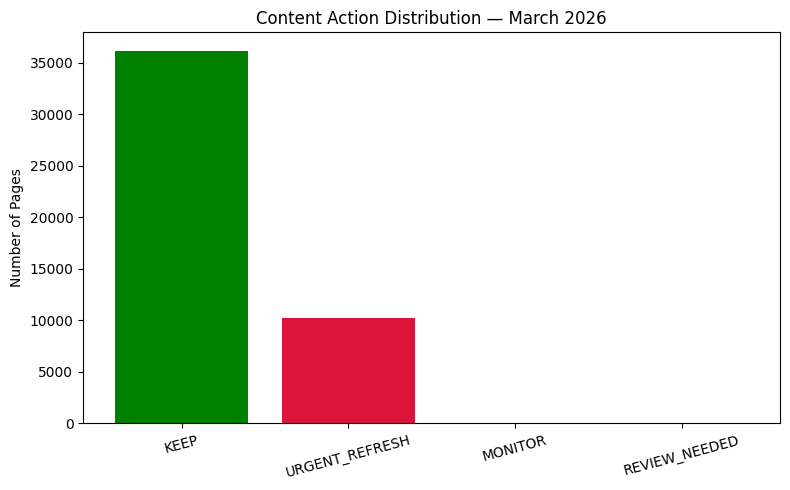

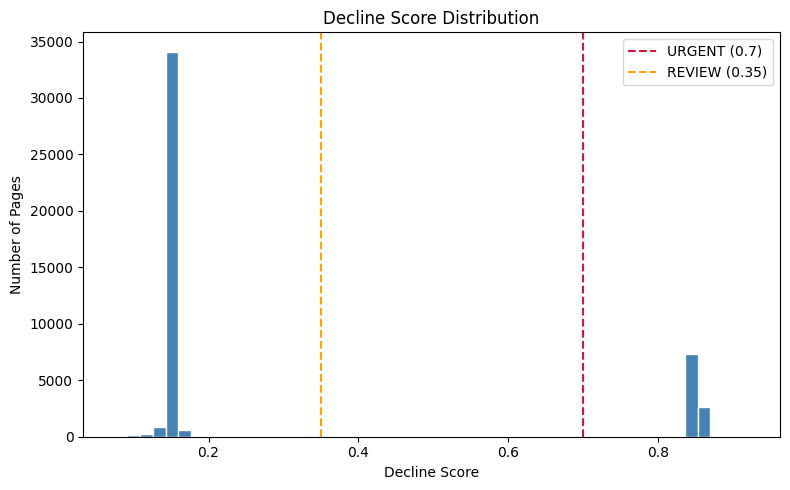

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================
# SECTION 5: EXPORTS FOR THE PAPER
# ============================================

import os

# Create output directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export 1: Ranked Queue CSV
playbook.to_csv('work/outputs/content_action_playbook.csv', index=False)
print("✅ Exported: work/outputs/content_action_playbook.csv")

# Export 2: Top 50 for paper
playbook.head(50).to_csv('work/outputs/top50_refresh_queue.csv', index=False)
print("✅ Exported: work/outputs/top50_refresh_queue.csv")

# Export 3: Action summary
action_summary = playbook['action'].value_counts().reset_index()
action_summary.columns = ['Action', 'Count']
action_summary.to_csv('work/outputs/action_summary.csv', index=False)
print("✅ Exported: work/outputs/action_summary.csv")

# Export 4: Action distribution figure
plt.figure(figsize=(8,5))
action_counts = playbook['action'].value_counts()
colors = {'URGENT_REFRESH': 'crimson', 'REVIEW_NEEDED': 'orange',
          'MONITOR': 'gold', 'KEEP': 'green'}
plt.bar(action_counts.index, action_counts.values,
        color=[colors.get(a, 'gray') for a in action_counts.index])
plt.title('Content Action Distribution — March 2026')
plt.ylabel('Number of Pages')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png', dpi=150, bbox_inches='tight')
print("✅ Exported: work/figures/action_distribution.png")

# Export 5: Score distribution
plt.figure(figsize=(8,5))
plt.hist(playbook['decline_score'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0.7, color='crimson', linestyle='--', label='URGENT (0.7)')
plt.axvline(x=0.35, color='orange', linestyle='--', label='REVIEW (0.35)')
plt.title('Decline Score Distribution')
plt.xlabel('Decline Score')
plt.ylabel('Number of Pages')
plt.legend()
plt.tight_layout()
plt.savefig('work/figures/score_distribution.png', dpi=150, bbox_inches='tight')
print("✅ Exported: work/figures/score_distribution.png")

print("\n✅ All exports complete! Ready for the paper!")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.